In [1]:
!pip install ucimlrepo

from ucimlrepo import fetch_ucirepo
import pandas as pd

dataset = fetch_ucirepo(id=697)
X = dataset.data.features
y = dataset.data.targets

df = pd.concat([X, y], axis=1)

In [2]:
df.head()

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [3]:
print("Shape:", df.shape)

Shape: (4424, 37)


In [4]:
print("Columns:", df.columns.tolist())

Columns: ['Marital Status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP', 'Target']


In [5]:
print(df.dtypes)

Marital Status                                      int64
Application mode                                    int64
Application order                                   int64
Course                                              int64
Daytime/evening attendance                          int64
Previous qualification                              int64
Previous qualification (grade)                    float64
Nacionality                                         int64
Mother's qualification                              int64
Father's qualification                              int64
Mother's occupation                                 int64
Father's occupation                                 int64
Admission grade                                   float64
Displaced                                           int64
Educational special needs                           int64
Debtor                                              int64
Tuition fees up to date                             int64
Gender        

In [6]:
print(df['Target'].value_counts())

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


In [7]:
print("Missing values per column:\n")
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())

Missing values per column:

Marital Status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                  

In [8]:
print("Number of duplicate rows:", df.duplicated().sum())

# Agar duplicates hain to remove karo
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Number of duplicate rows: 0
Shape after removing duplicates: (4424, 37)


In [9]:
# Data types recheck
print(df.dtypes.value_counts())

# Unique values check for target/categorical-looking columns (consistency check)
print(df['Target'].unique())
print(df['Gender'].unique())
print(df['Marital Status'].unique())

int64      29
float64     7
object      1
Name: count, dtype: int64
['Dropout' 'Graduate' 'Enrolled']
[1 0]
[1 2 4 3 5 6]


In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Target_encoded'] = le.fit_transform(df['Target'])

# Check mapping
print(dict(zip(le.classes_, le.transform(le.classes_))))
print(df[['Target', 'Target_encoded']].head())

{'Dropout': np.int64(0), 'Enrolled': np.int64(1), 'Graduate': np.int64(2)}
     Target  Target_encoded
0   Dropout               0
1  Graduate               2
2   Dropout               0
3  Graduate               2
4  Graduate               2


In [11]:
from sklearn.preprocessing import StandardScaler

# Numeric features ko scale karna (Target/Target_encoded ko chhod kar)
features = df.drop(columns=['Target', 'Target_encoded'])
scaler = StandardScaler()
scaled_features = pd.DataFrame(scaler.fit_transform(features), columns=features.columns)

scaled_features.head()

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
0,-0.294829,-0.095470,2.490896,-4.209520,0.350082,-0.35023,-0.804841,-0.126298,-0.036018,-0.669778,...,-0.199273,-0.282442,-2.838337,-2.042630,-1.471527,-1.963489,-0.199441,-0.287638,0.124386,0.765761
1,-0.294829,-0.209869,-0.554068,0.192580,0.350082,-0.35023,2.076819,-0.126298,-1.189759,-1.256427,...,-0.199273,-0.282442,-0.105726,-0.522682,0.518904,0.659562,-0.199441,0.876222,-1.105222,0.347199
2,-0.294829,-1.010660,2.490896,0.103404,0.350082,-0.35023,-0.804841,-0.126298,1.117723,0.959802,...,-0.199273,-0.282442,-0.105726,-2.042630,-1.471527,-1.963489,-0.199441,-0.287638,0.124386,0.765761
3,-0.294829,-0.095470,0.207173,0.444115,0.350082,-0.35023,-0.804841,-0.126298,1.181819,0.959802,...,-0.199273,-0.282442,-0.105726,0.490616,0.187165,0.416450,-0.199441,-0.813253,-1.466871,-1.375511
4,1.356212,1.162916,-0.554068,-0.408389,-2.856470,-0.35023,-2.473171,-0.126298,1.117723,1.024985,...,-0.199273,-0.282442,-0.105726,-0.522682,0.518904,0.531608,-0.199441,0.876222,-1.105222,0.347199


In [12]:
# Final dataset ready for model training
final_df = scaled_features.copy()
final_df['Target'] = df['Target_encoded']

print("Final dataset shape:", final_df.shape)
final_df.head()

Final dataset shape: (4424, 37)


,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,-0.294829,-0.095470,2.490896,-4.209520,0.350082,-0.35023,-0.804841,-0.126298,-0.036018,-0.669778,...,-0.282442,-2.838337,-2.042630,-1.471527,-1.963489,-0.199441,-0.287638,0.124386,0.765761,0
1,-0.294829,-0.209869,-0.554068,0.192580,0.350082,-0.35023,2.076819,-0.126298,-1.189759,-1.256427,...,-0.282442,-0.105726,-0.522682,0.518904,0.659562,-0.199441,0.876222,-1.105222,0.347199,2
2,-0.294829,-1.010660,2.490896,0.103404,0.350082,-0.35023,-0.804841,-0.126298,1.117723,0.959802,...,-0.282442,-0.105726,-2.042630,-1.471527,-1.963489,-0.199441,-0.287638,0.124386,0.765761,0
3,-0.294829,-0.095470,0.207173,0.444115,0.350082,-0.35023,-0.804841,-0.126298,1.181819,0.959802,...,-0.282442,-0.105726,0.490616,0.187165,0.416450,-0.199441,-0.813253,-1.466871,-1.375511,2
4,1.356212,1.162916,-0.554068,-0.408389,-2.856470,-0.35023,-2.473171,-0.126298,1.117723,1.024985,...,-0.282442,-0.105726,-0.522682,0.518904,0.531608,-0.199441,0.876222,-1.105222,0.347199,2


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

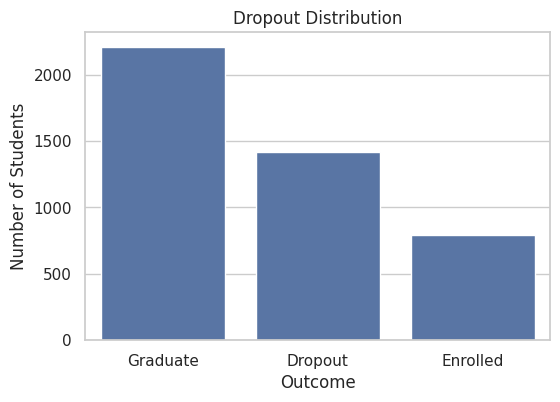

Target
Graduate    49.932188
Dropout     32.120253
Enrolled    17.947559
Name: proportion, dtype: float64


In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x='Target', data=df, order=df['Target'].value_counts().index)
plt.title("Dropout Distribution")
plt.xlabel("Outcome")
plt.ylabel("Number of Students")
plt.show()

print(df['Target'].value_counts(normalize=True) * 100)

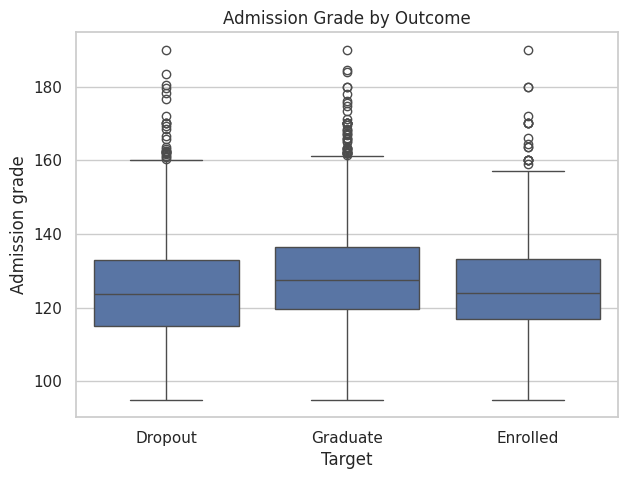

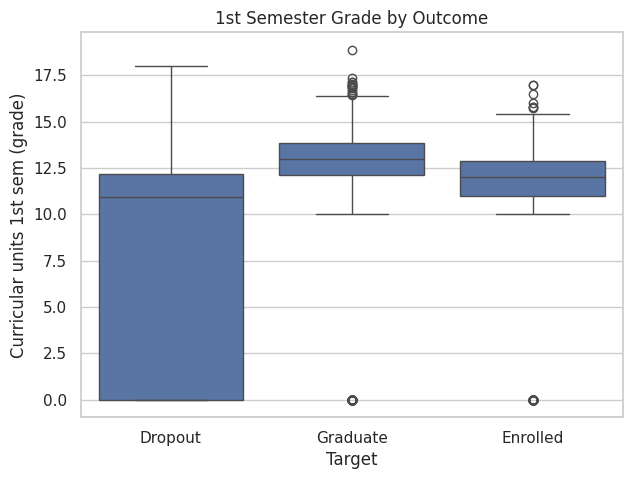

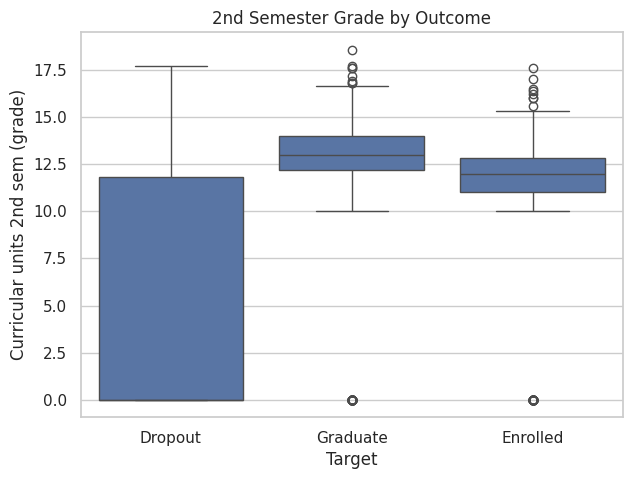

In [15]:
# Admission grade vs Target
plt.figure(figsize=(7,5))
sns.boxplot(x='Target', y='Admission grade', data=df)
plt.title("Admission Grade by Outcome")
plt.show()

# 1st semester grade vs Target
plt.figure(figsize=(7,5))
sns.boxplot(x='Target', y='Curricular units 1st sem (grade)', data=df)
plt.title("1st Semester Grade by Outcome")
plt.show()

# 2nd semester grade vs Target
plt.figure(figsize=(7,5))
sns.boxplot(x='Target', y='Curricular units 2nd sem (grade)', data=df)
plt.title("2nd Semester Grade by Outcome")
plt.show()

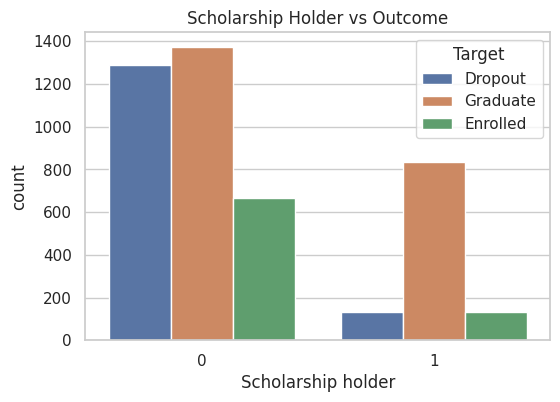

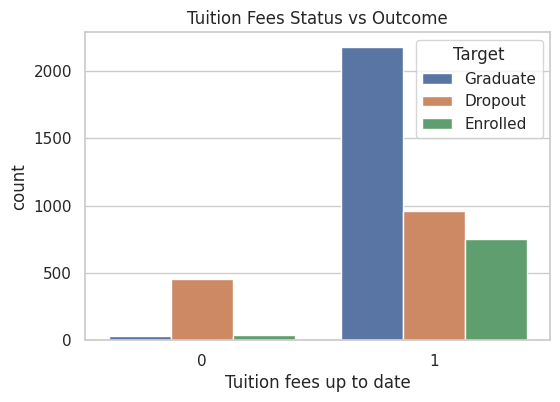

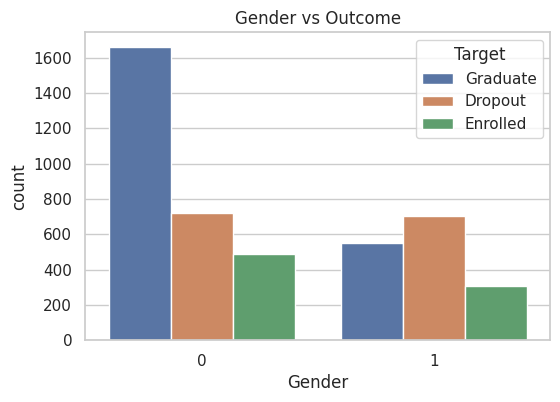

In [16]:
# Scholarship holder vs Target
plt.figure(figsize=(6,4))
sns.countplot(x='Scholarship holder', hue='Target', data=df)
plt.title("Scholarship Holder vs Outcome")
plt.show()

# Tuition fees up to date vs Target
plt.figure(figsize=(6,4))
sns.countplot(x='Tuition fees up to date', hue='Target', data=df)
plt.title("Tuition Fees Status vs Outcome")
plt.show()

# Gender vs Target
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', hue='Target', data=df)
plt.title("Gender vs Outcome")
plt.show()

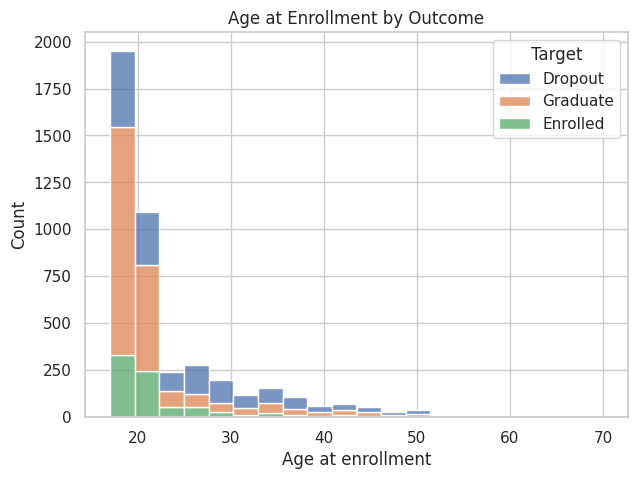

In [17]:
plt.figure(figsize=(7,5))
sns.histplot(data=df, x='Age at enrollment', hue='Target', multiple='stack', bins=20)
plt.title("Age at Enrollment by Outcome")
plt.show()

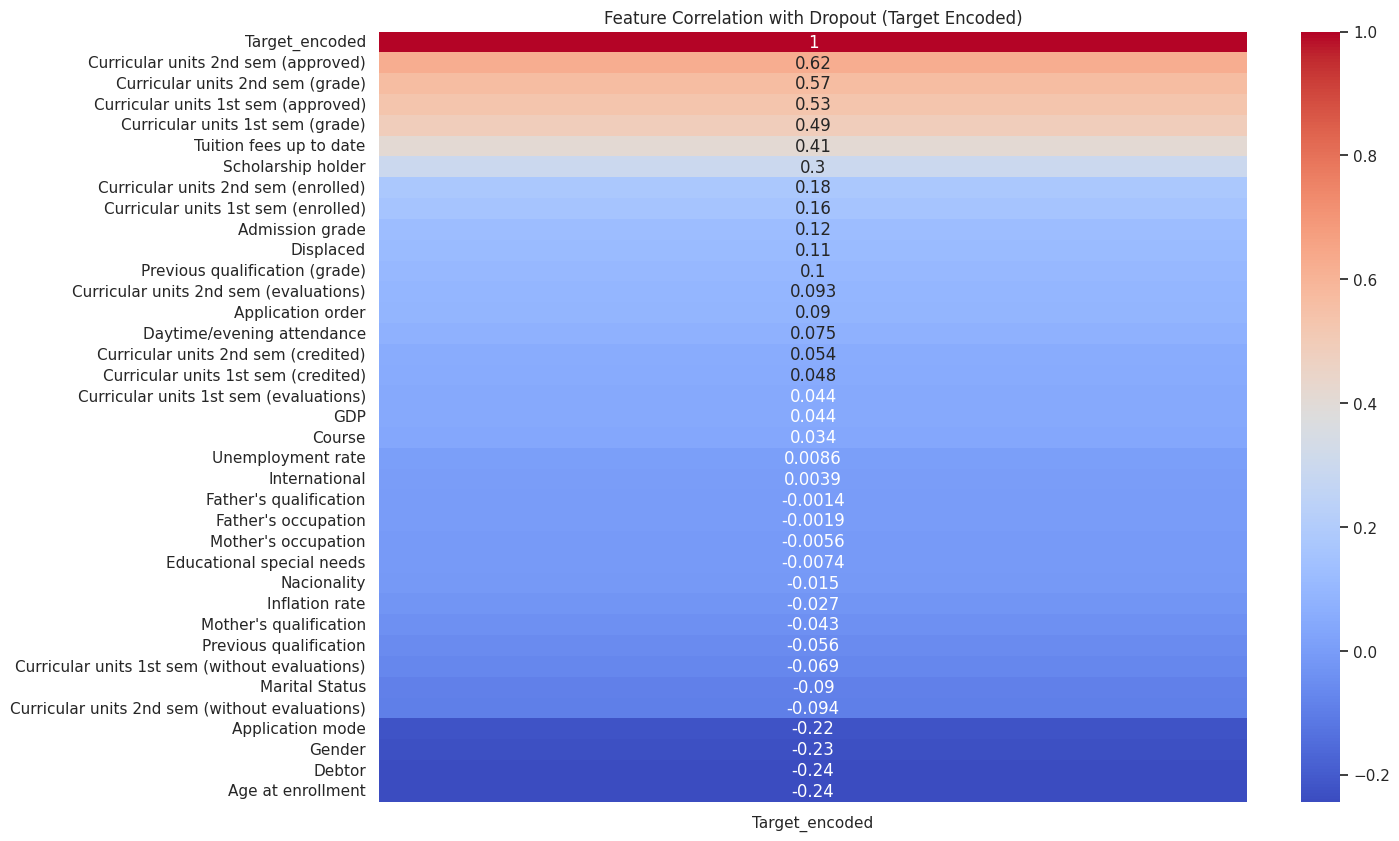

In [18]:
plt.figure(figsize=(14,10))
numeric_df = df.select_dtypes(include=['int64','float64']).copy()
numeric_df['Target_encoded'] = df['Target_encoded']

corr = numeric_df.corr()
sns.heatmap(corr[['Target_encoded']].sort_values(by='Target_encoded', ascending=False),
            annot=True, cmap='coolwarm')
plt.title("Feature Correlation with Dropout (Target Encoded)")
plt.show()

In [19]:
top_corr = corr['Target_encoded'].sort_values(ascending=False)
print(top_corr)

Target_encoded                                    1.000000
Curricular units 2nd sem (approved)               0.624157
Curricular units 2nd sem (grade)                  0.566827
Curricular units 1st sem (approved)               0.529123
Curricular units 1st sem (grade)                  0.485207
Tuition fees up to date                           0.409827
Scholarship holder                                0.297595
Curricular units 2nd sem (enrolled)               0.175847
Curricular units 1st sem (enrolled)               0.155974
Admission grade                                   0.120889
Displaced                                         0.113986
Previous qualification (grade)                    0.103764
Curricular units 2nd sem (evaluations)            0.092721
Application order                                 0.089791
Daytime/evening attendance                        0.075107
Curricular units 2nd sem (credited)               0.054004
Curricular units 1st sem (credited)               0.0481

In [20]:
# Binary target: Dropout = 1, Enrolled/Graduate = 0
df['Dropout_binary'] = df['Target'].apply(lambda x: 1 if x == 'Dropout' else 0)

print(df['Dropout_binary'].value_counts())

Dropout_binary
0    3003
1    1421
Name: count, dtype: int64


In [21]:
X = df.drop(columns=['Target', 'Target_encoded', 'Dropout_binary'])
y = df['Dropout_binary']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (4424, 36)
Target shape: (4424,)


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("Training target distribution:\n", y_train.value_counts())
print("Testing target distribution:\n", y_test.value_counts())

Training set shape: (3539, 36)
Testing set shape: (885, 36)
Training target distribution:
 Dropout_binary
0    2402
1    1137
Name: count, dtype: int64
Testing target distribution:
 Dropout_binary
0    601
1    284
Name: count, dtype: int64


In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

print("Model trained successfully!")

Model trained successfully!


In [25]:
y_pred = model.predict(X_test_scaled)

print("Predictions (first 20):", y_pred[:20])

Predictions (first 20): [0 0 1 0 1 0 1 1 0 1 1 0 1 0 0 0 1 0 0 0]


In [26]:
y_pred_proba = model.predict_proba(X_test_scaled)

print("Prediction probabilities (first 5 rows):")
print(y_pred_proba[:5])
# Column 0 = probability of "Not Dropout", Column 1 = probability of "Dropout"

Prediction probabilities (first 5 rows):
[[0.97765291 0.02234709]
 [0.7483755  0.2516245 ]
 [0.02760728 0.97239272]
 [0.97685483 0.02314517]
 [0.0541236  0.9458764 ]]


In [27]:
from sklearn.metrics import accuracy_score

train_accuracy = model.score(X_train_scaled, y_train)
test_accuracy = model.score(X_test_scaled, y_test)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 0.8770839220118678
Testing Accuracy: 0.8858757062146893


Confusion Matrix:
 [[575  26]
 [ 75 209]]


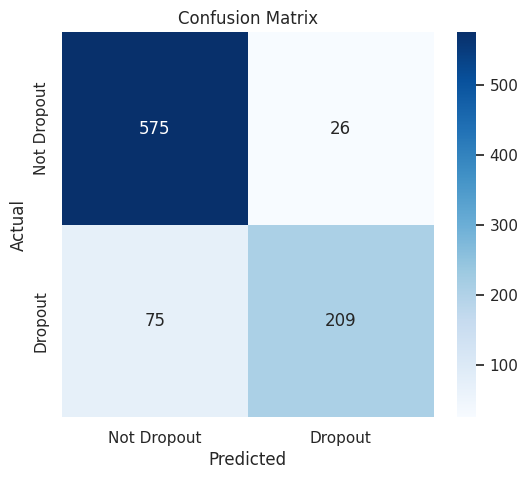

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Dropout', 'Dropout'],
            yticklabels=['Not Dropout', 'Dropout'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [29]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=['Not Dropout', 'Dropout']))

              precision    recall  f1-score   support

 Not Dropout       0.88      0.96      0.92       601
     Dropout       0.89      0.74      0.81       284

    accuracy                           0.89       885
   macro avg       0.89      0.85      0.86       885
weighted avg       0.89      0.89      0.88       885



In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.8858757062146893
Precision: 0.8893617021276595
Recall: 0.7359154929577465
F1 Score: 0.8053949903660886


ROC-AUC Score: 0.9266070633451289


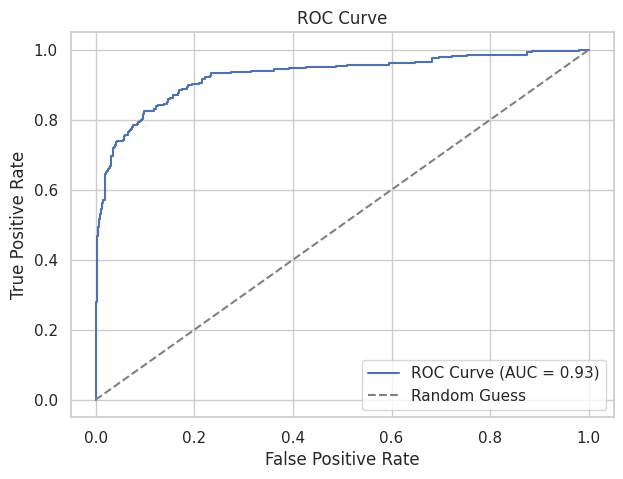

In [31]:
from sklearn.metrics import roc_auc_score, roc_curve

roc_auc = roc_auc_score(y_test, y_pred_proba[:, 1])
print("ROC-AUC Score:", roc_auc)

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba[:, 1])

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [32]:
tn, fp, fn, tp = cm.ravel()

print("True Negatives (correctly predicted Not Dropout):", tn)
print("False Positives (predicted Dropout, actually Not Dropout):", fp)
print("False Negatives (predicted Not Dropout, actually Dropout):", fn)
print("True Positives (correctly predicted Dropout):", tp)

print("\nInterpretation:")
print(f"- {fn} at-risk students were missed by the model (False Negatives) — these are the most costly errors since these students needed intervention but weren't flagged.")
print(f"- {fp} students were incorrectly flagged as at-risk (False Positives) — this means some support resources may be spent on students who weren't actually going to drop out.")

True Negatives (correctly predicted Not Dropout): 575
False Positives (predicted Dropout, actually Not Dropout): 26
False Negatives (predicted Not Dropout, actually Dropout): 75
True Positives (correctly predicted Dropout): 209

Interpretation:
- 75 at-risk students were missed by the model (False Negatives) — these are the most costly errors since these students needed intervention but weren't flagged.
- 26 students were incorrectly flagged as at-risk (False Positives) — this means some support resources may be spent on students who weren't actually going to drop out.


In [33]:
import numpy as np
import pandas as pd

def predict_dropout_risk(student_data):
    """
    student_data: dictionary with same feature names as training data
    Returns: probability of dropout + risk category
    """
    # Convert input into DataFrame with same column order as training features
    input_df = pd.DataFrame([student_data], columns=X.columns)

    # Scale using the same scaler used during training
    input_scaled = scaler.transform(input_df)

    # Predict probability
    probability = model.predict_proba(input_scaled)[0][1]  # probability of Dropout (class 1)
    prediction = model.predict(input_scaled)[0]

    # Risk category based

In [34]:
# Example: build one input row using average/sample values for all features
# Print column names first, so you know what to fill in
print(X.columns.tolist())

['Marital Status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP']


In [35]:
student_1 = {
    'Marital Status': 1, 'Application mode': 1, 'Application order': 1, 'Course': 9500,
    'Daytime/evening attendance': 1, 'Previous qualification': 1, 'Previous qualification (grade)': 150,
    'Nacionality': 1, "Mother's qualification": 19, "Father's qualification": 12,
    "Mother's occupation": 5, "Father's occupation": 5, 'Admission grade': 150,
    'Displaced': 0, 'Educational special needs': 0, 'Debtor': 0, 'Tuition fees up to date': 1,
    'Gender': 0, 'Scholarship holder': 1, 'Age at enrollment': 18, 'International': 0,
    'Curricular units 1st sem (credited)': 0, 'Curricular units 1st sem (enrolled)': 6,
    'Curricular units 1st sem (evaluations)': 6, 'Curricular units 1st sem (approved)': 6,
    'Curricular units 1st sem (grade)': 15, 'Curricular units 1st sem (without evaluations)': 0,
    'Curricular units 2nd sem (credited)': 0, 'Curricular units 2nd sem (enrolled)': 6,
    'Curricular units 2nd sem (evaluations)': 6, 'Curricular units 2nd sem (approved)': 6,
    'Curricular units 2nd sem (grade)': 15, 'Curricular units 2nd sem (without evaluations)': 0,
    'Unemployment rate': 10.8, 'Inflation rate': 1.4, 'GDP': 1.74
}

result_1 = predict_dropout_risk(student_1)
print("Test Case 1 (Expected: Low Risk):", result_1)

Test Case 1 (Expected: Low Risk): None


In [36]:
student_2 = {
    'Marital Status': 1, 'Application mode': 17, 'Application order': 3, 'Course': 9773,
    'Daytime/evening attendance': 0, 'Previous qualification': 1, 'Previous qualification (grade)': 100,
    'Nacionality': 1, "Mother's qualification": 37, "Father's qualification": 37,
    "Mother's occupation": 9, "Father's occupation": 9, 'Admission grade': 95,
    'Displaced': 1, 'Educational special needs': 0, 'Debtor': 1, 'Tuition fees up to date': 0,
    'Gender': 1, 'Scholarship holder': 0, 'Age at enrollment': 25, 'International': 0,
    'Curricular units 1st sem (credited)': 0, 'Curricular units 1st sem (enrolled)': 6,
    'Curricular units 1st sem (evaluations)': 3, 'Curricular units 1st sem (approved)': 1,
    'Curricular units 1st sem (grade)': 8, 'Curricular units 1st sem (without evaluations)': 2,
    'Curricular units 2nd sem (credited)': 0, 'Curricular units 2nd sem (enrolled)': 6,
    'Curricular units 2nd sem (evaluations)': 2, 'Curricular units 2nd sem (approved)': 0,
    'Curricular units 2nd sem (grade)': 0, 'Curricular units 2nd sem (without evaluations)': 3,
    'Unemployment rate': 13.9, 'Inflation rate': -0.3, 'GDP': 0.79
}

result_2 = predict_dropout_risk(student_2)
print("Test Case 2 (Expected: High Risk):", result_2)

Test Case 2 (Expected: High Risk): None


In [37]:
student_3 = {
    'Marital Status': 1, 'Application mode': 15, 'Application order': 2, 'Course': 9254,
    'Daytime/evening attendance': 1, 'Previous qualification': 1, 'Previous qualification (grade)': 130,
    'Nacionality': 1, "Mother's qualification": 19, "Father's qualification": 19,
    "Mother's occupation": 5, "Father's occupation": 5, 'Admission grade': 120,
    'Displaced': 0, 'Educational special needs': 0, 'Debtor': 0, 'Tuition fees up to date': 1,
    'Gender': 0, 'Scholarship holder': 0, 'Age at enrollment': 20, 'International': 0,
    'Curricular units 1st sem (credited)': 0, 'Curricular units 1st sem (enrolled)': 6,
    'Curricular units 1st sem (evaluations)': 6, 'Curricular units 1st sem (approved)': 4,
    'Curricular units 1st sem (grade)': 11, 'Curricular units 1st sem (without evaluations)': 0,
    'Curricular units 2nd sem (credited)': 0, 'Curricular units 2nd sem (enrolled)': 6,
    'Curricular units 2nd sem (evaluations)': 6, 'Curricular units 2nd sem (approved)': 4,
    'Curricular units 2nd sem (grade)': 12, 'Curricular units 2nd sem (without evaluations)': 0,
    'Unemployment rate': 9.4, 'Inflation rate': -0.8, 'GDP': -3.12
}

result_3 = predict_dropout_risk(student_3)
print("Test Case 3 (Expected: Medium Risk):", result_3)

Test Case 3 (Expected: Medium Risk): None


In [38]:
from ipywidgets import interact_manual, IntSlider, FloatSlider, Dropdown

def interactive_predict(admission_grade, sem1_grade, sem2_grade, tuition_paid, scholarship, age):
    student = student_1.copy()  # start with base template
    student['Admission grade'] = admission_grade
    student['Curricular units 1st sem (grade)'] = sem1_grade
    student['Curricular units 2nd sem (grade)'] = sem2_grade
    student['Tuition fees up to date'] = tuition_paid
    student['Scholarship holder'] = scholarship
    student['Age at enrollment'] = age

    result = predict_dropout_risk(student)
    print(result)

interact_manual(interactive_predict,
    admission_grade=FloatSlider(min=0, max=200, value=120),
    sem1_grade=FloatSlider(min=0, max=20, value=12),
    sem2_grade=FloatSlider(min=0, max=20, value=12),
    tuition_paid=Dropdown(options=[0,1], value=1),
    scholarship=Dropdown(options=[0,1], value=0),
    age=IntSlider(min=17, max=50, value=20)
)

interactive(children=(FloatSlider(value=120.0, description='admission_grade', max=200.0), FloatSlider(value=12…

<function __main__.interactive_predict(admission_grade, sem1_grade, sem2_grade, tuition_paid, scholarship, age)>